In [1]:
!pip install kagglehub --upgrade


In [2]:
import kagglehub

path = kagglehub.dataset_download("ismailnasri20/driver-drowsiness-dataset-ddd")

print(" Dataset downloaded to:", path)


100%|██████████| 2.58G/2.58G [01:59<00:00, 23.2MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/versions/1


In [3]:
import os

for file in os.listdir(path):
    print(file)


Driver Drowsiness Dataset (DDD)


In [5]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for d in dirs:
        print(f"{subindent}{d}/")
    for f in files[:3]:
        print(f"{subindent}{f}")


1/
    Driver Drowsiness Dataset (DDD)/
    Driver Drowsiness Dataset (DDD)/
        Drowsy/
        Non Drowsy/
        Drowsy/
            F0101.png
            F0378.png
            ZC1296.png
        Non Drowsy/
            k0185.png
            a0041.png
            e0497.png


In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split

base_path = os.path.join(path, "Driver Drowsiness Dataset (DDD)")

output_base = os.path.join(path, "split_dataset")
train_dir = os.path.join(output_base, "train")
test_dir = os.path.join(output_base, "test")

for folder in [train_dir, test_dir]:
    for cls in ["Drowsy", "Non Drowsy"]:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

for cls in ["Drowsy", "Non Drowsy"]:
    cls_path = os.path.join(base_path, cls)
    images = os.listdir(cls_path)
    train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))
    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(test_dir, cls, img))

print("Dataset successfully split into train/test folders!")
print(f"Train folder: {train_dir}")
print(f"Test folder:  {test_dir}")


✅ Dataset successfully split into train/test folders!
Train folder: /root/.cache/kagglehub/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/versions/1/split_dataset/train
Test folder:  /root/.cache/kagglehub/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/versions/1/split_dataset/test


In [11]:
class_names = train_ds.classes
class_names

['Drowsy', 'Non Drowsy']

In [18]:
img, label = train_ds[0]
img = img.squeeze()
img.shape

print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")


Image tensor:
tensor([[[0.2549, 0.2549, 0.2471,  ..., 0.3412, 0.3490, 0.3451],
         [0.2588, 0.2627, 0.2549,  ..., 0.3412, 0.3451, 0.3451],
         [0.2784, 0.2784, 0.2627,  ..., 0.3490, 0.3569, 0.3529],
         ...,
         [0.9765, 0.9765, 0.9725,  ..., 0.9137, 0.9137, 0.9216],
         [0.9176, 0.9176, 0.9176,  ..., 0.9216, 0.9216, 0.9255],
         [0.8980, 0.8902, 0.8941,  ..., 0.9333, 0.9294, 0.9373]],

        [[0.2000, 0.2000, 0.1922,  ..., 0.2627, 0.2706, 0.2745],
         [0.2039, 0.2078, 0.2000,  ..., 0.2627, 0.2667, 0.2784],
         [0.2235, 0.2235, 0.2078,  ..., 0.2745, 0.2824, 0.2863],
         ...,
         [0.9294, 0.9294, 0.9216,  ..., 0.8510, 0.8510, 0.8510],
         [0.8627, 0.8588, 0.8588,  ..., 0.8471, 0.8510, 0.8471],
         [0.8314, 0.8275, 0.8314,  ..., 0.8510, 0.8549, 0.8549]],

        [[0.1412, 0.1412, 0.1333,  ..., 0.1804, 0.1882, 0.1882],
         [0.1451, 0.1451, 0.1412,  ..., 0.1804, 0.1843, 0.1922],
         [0.1647, 0.1647, 0.1490,  ..., 0.19

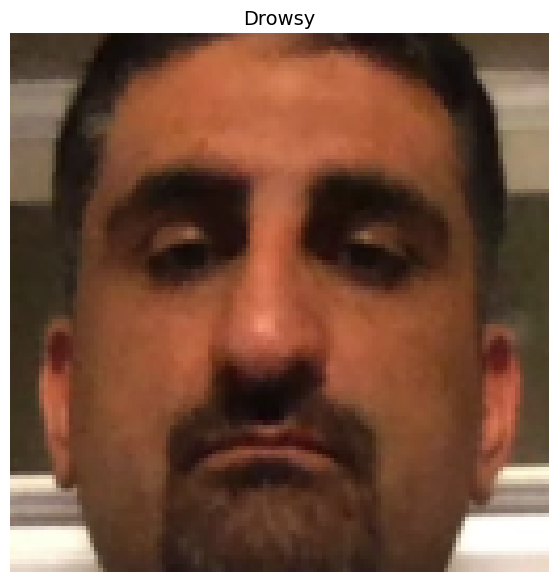

In [20]:
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

In [27]:
import torch
import random
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: list[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    if seed:
        random.seed(seed)

    random_samples_idx = random.sample(range(len(dataset)), k=n)

    plt.figure(figsize=(16, 8))

    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        targ_image_adjust = targ_image.permute(1, 2, 0)

        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

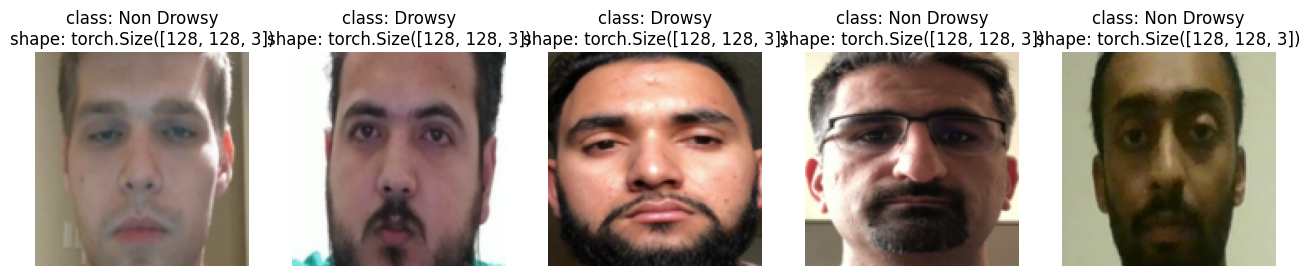

In [28]:
display_random_images(train_ds,
                      n=5,
                      classes=class_names,
                      seed=None)

In [30]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

train_ds = datasets.ImageFolder(os.path.join(output_base, "train"), transform=transform)
test_ds = datasets.ImageFolder(os.path.join(output_base, "test"), transform=transform)

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_loader = DataLoader(train_ds,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))


Train samples: 33434
Test samples: 8359


In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [38]:
from torch import nn
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*BATCH_SIZE*BATCH_SIZE,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)
model = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_ds.classes)).to(device)
model

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=10240, out_features=2, bias=True)
  )
)

In [39]:
img_batch, label_batch = next(iter(train_loader))

img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

model.eval()
with torch.inference_mode():
    pred = model(img_single.to(device))

print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 128, 128])

Output logits:
tensor([[-0.0521,  0.0108]], device='cuda:0')

Output prediction probabilities:
tensor([[0.4843, 0.5157]], device='cuda:0')

Output prediction label:
tensor([1], device='cuda:0')

Actual label:
1


In [41]:
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model, input_size=[1, 3, 128, 128])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 2]                    --
├─Sequential: 1-1                        [1, 10, 64, 64]           --
│    └─Conv2d: 2-1                       [1, 10, 128, 128]         280
│    └─ReLU: 2-2                         [1, 10, 128, 128]         --
│    └─Conv2d: 2-3                       [1, 10, 128, 128]         910
│    └─ReLU: 2-4                         [1, 10, 128, 128]         --
│    └─MaxPool2d: 2-5                    [1, 10, 64, 64]           --
├─Sequential: 1-2                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-6                       [1, 10, 64, 64]           910
│    └─ReLU: 2-7                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-8                       [1, 10, 64, 64]           910
│    └─ReLU: 2-9                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-10                   [1, 10, 32, 32]           --
├─Sequentia

In [42]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [43]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


In [44]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results


In [46]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

model = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_ds.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

from timeit import default_timer as timer
start_time = timer()

model_results = train(model=model,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.1731 | train_acc: 0.9151 | test_loss: 0.0402 | test_acc: 0.9874
Epoch: 2 | train_loss: 0.0265 | train_acc: 0.9922 | test_loss: 0.0131 | test_acc: 0.9958
Epoch: 3 | train_loss: 0.0194 | train_acc: 0.9943 | test_loss: 0.0088 | test_acc: 0.9974
Epoch: 4 | train_loss: 0.0136 | train_acc: 0.9955 | test_loss: 0.0253 | test_acc: 0.9915
Epoch: 5 | train_loss: 0.0129 | train_acc: 0.9961 | test_loss: 0.0153 | test_acc: 0.9940
Total training time: 589.388 seconds


In [48]:
def plot_loss_curves(results):

    loss = results['train_loss']
    test_loss = results['test_loss']

    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

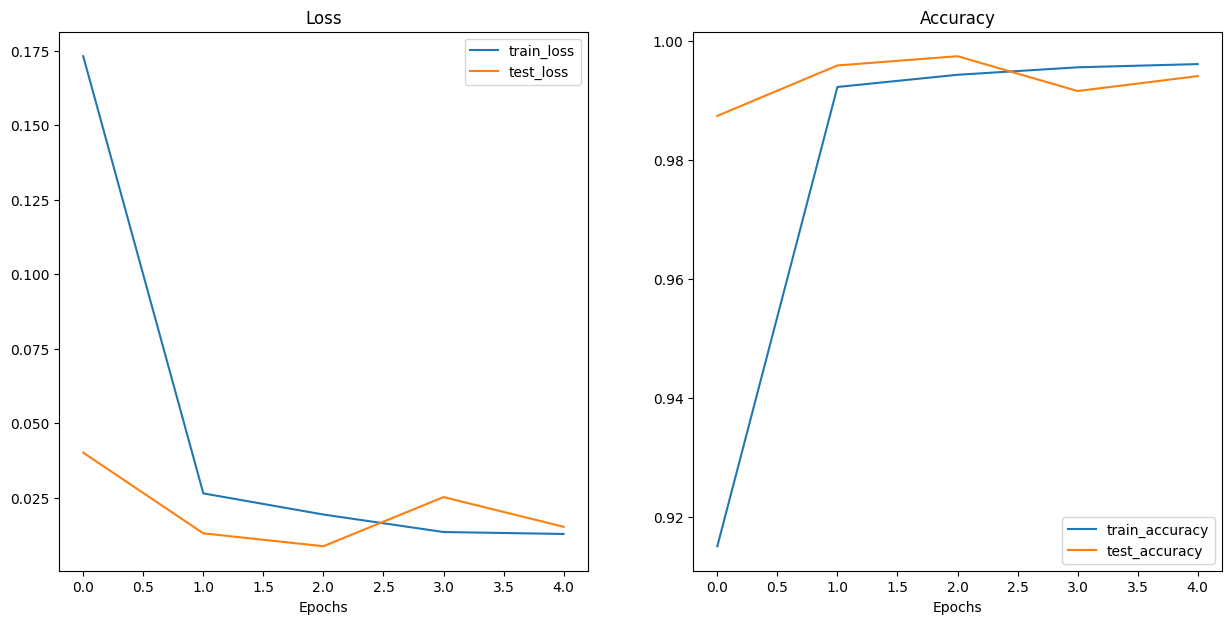

In [49]:
plot_loss_curves(model_results)